# 01 — EDA: Profiling, Cleaning & the Data Story

**Module:** Zepto analyst-to-data-scientist workflow · **Dataset:** classic *Titanic* (Seaborn built-in)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.width", 120)

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

def show_save(fig, name):
    fig.savefig(CHART_DIR / name, dpi=140)
    plt.show()
    plt.close(fig)
    print(f"-> charts/{name}")


### Task 1 — Load once, profile, save the offline fallback

In [2]:
df = sns.load_dataset("titanic")

print("df.shape:", df.shape)
print()
df.info()
print()
print("df.describe():")
print(df.describe().round(4))
print()

# Commit the RAW DataFrame immediately -- before any cleaning -- so that the
# module always has an offline fallback gradeable via pd.read_csv("titanic.csv").
df.to_csv("titanic.csv", index=False)
print("-> titanic.csv written (889 csv rows preserved; this is the raw load)")
print()

# Missing-value profile of the raw load
miss = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(4).values,
})
miss = miss[miss["missing_count"] > 0].sort_values("missing_%", ascending=False)
print("Columns with missing values (raw load):")
print(miss.to_string(index=False))


df.shape: (891, 15)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

df.describe():
       survived    pclass       age     sibsp     parch  

### Task 2 — Missing-value strategy: measured percentages first, then the threshold rule

Percentages measured on the raw load:

| column      | missing % | count | rule band                 | action                                  |
|-------------|-----------|-------|---------------------------|-----------------------------------------|
| `deck`      | 77.2166   | 688   | &gt; 30% (unreliable)     | **drop the column** (see justification) |
| `age`       | 19.8653   | 177   | 5%–30%                    | impute with median                      |
| `embarked`  | 0.2245    | 2     | under 5%                  | drop the 2 rows                         |
| `embark_town` | 0.2245  | 2     | under 5%                  | drop the 2 rows (same rows)             |

**Threshold rule applied:**
- missing **&lt; 5%** → drop those rows;
- missing **5% – 30%** → impute;
- missing **&gt; 30%** (imputation would be unreliable) → drop the column or encode "missing" as its own category.


In [3]:
clean = df.copy()

# deck: 77.2166% missing (> 30% band) -> DROP THE COLUMN (markdown justification below)
clean = clean.drop(columns=["deck"])

# age: 19.8653% missing (5-30% band) -> impute with the median
age_median = clean["age"].median()
clean["age"] = clean["age"].fillna(age_median)

# embarked / embark_town: 0.2245% (2 rows, < 5% band) -> drop those rows
clean = clean.dropna(subset=["embarked", "embark_town"])

print("age imputed with median =", age_median)
print("raw shape   :", df.shape)
print("clean shape :", clean.shape)
print("remaining missing cells:", int(clean.isna().sum().sum()))
print("survived class balance (cleaned):", round(clean["survived"].mean(), 4))


age imputed with median = 28.0
raw shape   : (891, 15)
clean shape : (889, 14)
remaining missing cells: 0
survived class balance (cleaned): 0.3825


**Why `deck` is dropped rather than imputed or re-coded:** `deck` is missing in **77.22%** of rows
(688/891), far above the 30% "imputation would be unreliable" ceiling. Imputing would fabricate ~77% of the
column's values — guessing far more data than we measure — which would inject a fictitious signal into every
downstream statistic. The usual alternative would be to encode "missing" as its own category; here that
would create an 8th bucket holding ~77% of the passengers, i.e. a near-constant, information-free column
(deck letter already correlates strongly with class/fare, which remain in the data). **Decision: drop
`deck`.** `age` (19.87%) is imputed with its median per the 5–30% band, and the 2 rows with missing
`embarked`/`embark_town` (0.22%) are dropped per the under-5% rule.


### Task 3 — Univariate analysis (histograms, box plots, IQR outliers, skewness)

`age` and `fare` each get a histogram and a box plot. Outliers are defined by the IQR rule — points outside
`[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`. We also report mean / median / mode for `fare` and use their ordering to
judge skewness.


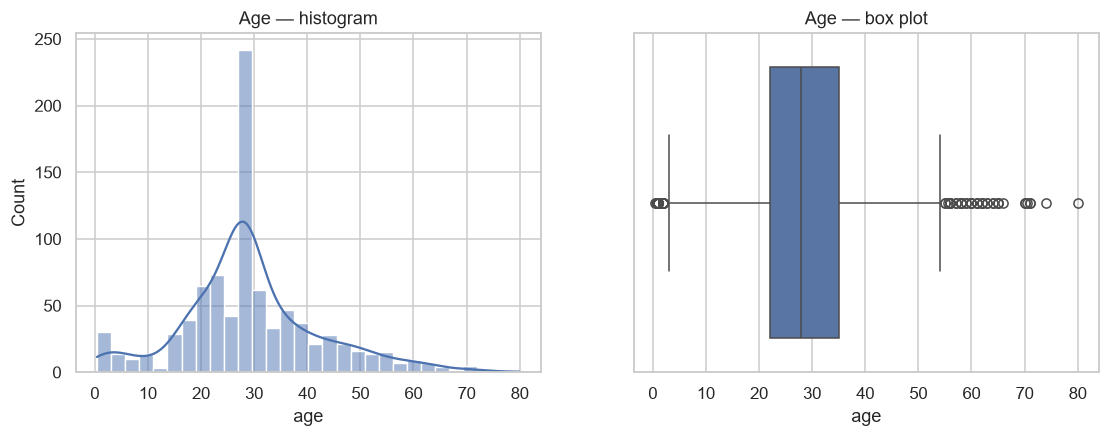

-> charts/age_hist_box.png


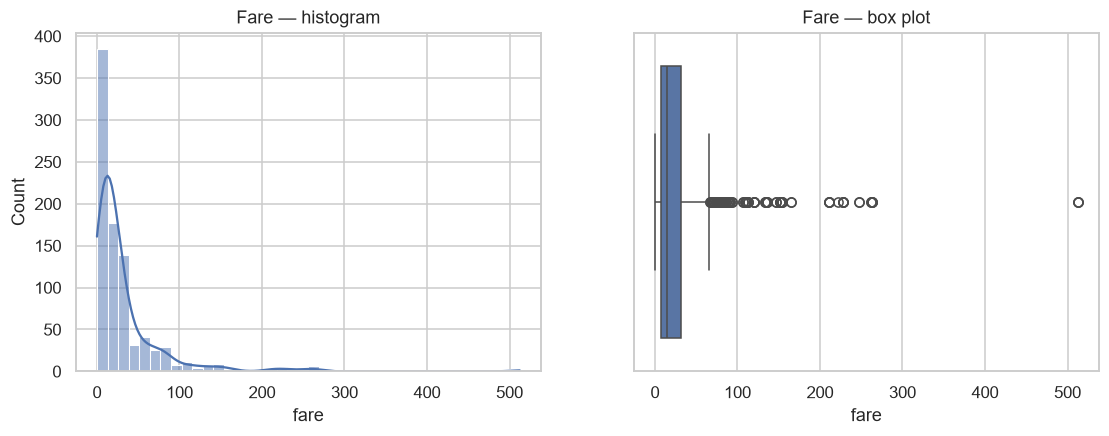

-> charts/fare_hist_box.png
 age: Q1=22.0000  Q3=35.0000  IQR=13.0000  outliers outside [2.5000, 54.5000] -> 65
fare: Q1=7.8958  Q3=31.0000  IQR=23.1042  outliers outside [-26.7605, 65.6563] -> 114
fare: mean=32.0967  median=14.4542  mode=8.0500


In [4]:
# Histogram + box plot for age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age — histogram")
sns.boxplot(x=clean["age"], ax=axes[1])
axes[1].set_title("Age — box plot")
show_save(fig, "age_hist_box.png")

# Histogram + box plot for fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["fare"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Fare — histogram")
sns.boxplot(x=clean["fare"], ax=axes[1])
axes[1].set_title("Fare — box plot")
show_save(fig, "fare_hist_box.png")

# IQR outlier counts: outliers = values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
for col in ["age", "fare"]:
    q1, q3 = clean[col].quantile(0.25), clean[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((clean[col] < lo) | (clean[col] > hi)).sum())
    print(f"{col:>4s}: Q1={q1:.4f}  Q3={q3:.4f}  IQR={iqr:.4f}  outliers outside [{lo:.4f}, {hi:.4f}] -> {n_out}")

# Central tendency of fare
fare_mean = clean["fare"].mean()
fare_med = clean["fare"].median()
fare_mode = float(clean["fare"].mode()[0])
print(f"fare: mean={fare_mean:.4f}  median={fare_med:.4f}  mode={fare_mode:.4f}")


**Outliers (IQR rule, cleaned data):** `age` → **65** outliers; `fare` → **114** outliers. The fare box plot
shows the long right tail clearly — a handful of very expensive first-class tickets ($200–$512) sits far
above the upper fence.

**Skewness of `fare`:** mean = **32.10**, median = **14.45**, mode = **8.05**. Because
**mean &gt; median &gt; mode**, the distribution is **right-skewed (positively skewed)**: the long right
tail of costly tickets pulls the mean well above the typical (median) fare, while most tickets pile up at
the low, most-frequent fare of $8.05.


### Task 4 — Bivariate analysis: boolean-mask survival rates & the 6×6 correlation heatmap

In [4]:
# (a)(b)(c) survival rates via boolean masking
def surv_rate(mask, tag=""):
    r = float(clean.loc[mask, "survived"].mean())
    print(f"  {tag:<34s} survival rate = {r:.4f}   (n={int(mask.sum())})")
    return r

print("(a) by sex")
for s in ["female", "male"]:
    surv_rate(clean["sex"] == s, tag=f"sex == '{s}'")

print("\n(b) by pclass")
for p in [1, 2, 3]:
    surv_rate(clean["pclass"] == p, tag=f"pclass == {p}")

print("\n(c) by sex AND pclass together (combined & masks)")
for s in ["female", "male"]:
    for p in [1, 2, 3]:
        surv_rate((clean["sex"] == s) & (clean["pclass"] == p),
                  tag=f"sex == '{s}' & pclass == {p}")


(a) by sex
  sex == 'female'                    survival rate = 0.7404   (n=312)
  sex == 'male'                      survival rate = 0.1889   (n=577)

(b) by pclass
  pclass == 1                        survival rate = 0.6262   (n=214)
  pclass == 2                        survival rate = 0.4728   (n=184)
  pclass == 3                        survival rate = 0.2424   (n=491)

(c) by sex AND pclass together (combined & masks)
  sex == 'female' & pclass == 1      survival rate = 0.9674   (n=92)
  sex == 'female' & pclass == 2      survival rate = 0.9211   (n=76)
  sex == 'female' & pclass == 3      survival rate = 0.5000   (n=144)
  sex == 'male' & pclass == 1        survival rate = 0.3689   (n=122)
  sex == 'male' & pclass == 2        survival rate = 0.1574   (n=108)
  sex == 'male' & pclass == 3        survival rate = 0.1354   (n=347)


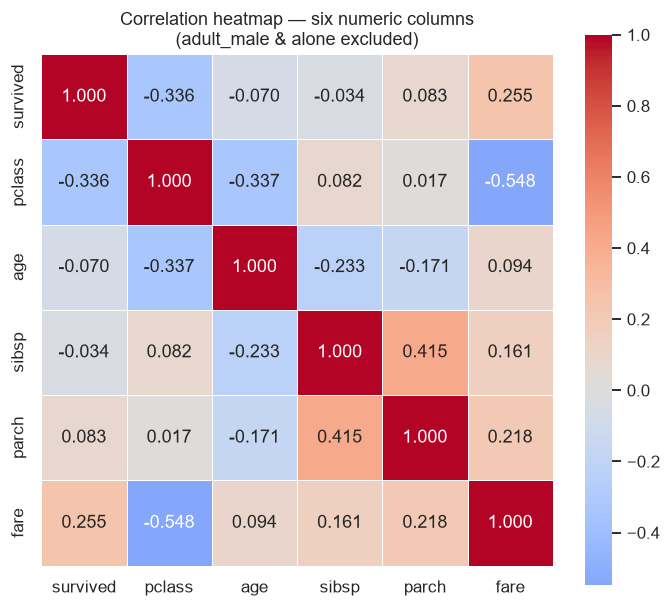

-> charts/corr_heatmap.png
Top 3 off-diagonal pairs by |correlation|:
  var1   var2         r    abs_r
pclass   fare -0.548193 0.548193
  fare pclass -0.548193 0.548193
 sibsp  parch  0.414542 0.414542


In [5]:
# Correlation matrix on exactly the six numeric columns
# (adult_male and alone are derived flags -> excluded by construction)
six = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr6 = clean[six].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr6, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation heatmap — six numeric columns\n(adult_male & alone excluded)")
show_save(fig, "corr_heatmap.png")

# Rank all off-diagonal pairs by |r| and take the top two
pairs = (corr6.where(~np.eye(len(corr6), dtype=bool)).stack().rename("r").reset_index())
pairs.columns = ["var1", "var2", "r"]
pairs["abs_r"] = pairs["r"].abs()
pairs = pairs.sort_values("abs_r", ascending=False)
print("Top 3 off-diagonal pairs by |correlation|:")
print(pairs.head(3).to_string(index=False))


**Bivariate survival rates (masked):**
- (a) by sex — female **74.04%** vs male **18.89%**;
- (b) by class — 1st **62.62%**, 2nd **47.28%**, 3rd **24.24%**;
- (c) sex × class — female/1st **96.74%**, female/2nd **92.11%**, female/3rd **50.00%**; male/1st **36.89%**,
  male/2nd **15.74%**, male/3rd **13.54%**.

**The two strongest correlations** (largest |r| among all off-diagonal pairs, measured on the 6×6 matrix):

1. **`pclass` ↔ `fare`, r = −0.5482** — by far the strongest pair. First class paid the highest fares and
   3rd class the lowest; because class negatively drives survival (r = −0.3355) while fare positively does
   (r = 0.2553), this pair anchors the whole narrative: socio-economic position (ticket price = class)
   strongly shaped survival odds.
2. **`sibsp` ↔ `parch`, r = 0.4145** — the two family-size components move together. Passengers who
   travelled with siblings/spouses also tended to travel with parents/children; together they define a
   "travelling with family" dimension (the exact redundancy that makes the `alone` flag derivable and
   therefore excluded here). Both have only weak direct links to survival (−0.034 and 0.083).


### Task 5 — Multivariate "data story": who survived and why

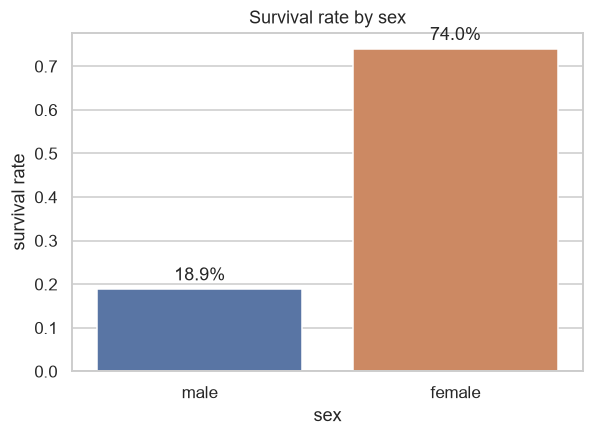

-> charts/bar_surv_by_sex.png


In [6]:
# --- Chart 1/6: survival rate by sex ---
rates_sex = clean.groupby("sex")["survived"].mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=rates_sex.index, y=rates_sex.values, hue=rates_sex.index, legend=False, ax=ax)
for i, v in enumerate(rates_sex.values):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
ax.set_ylabel("survival rate")
ax.set_title("Survival rate by sex")
show_save(fig, "bar_surv_by_sex.png")


**Chart 1 — Survival rate by sex.** Women survived at **74.0%** versus **18.9%** for men — roughly a 4× gap
and the single strongest demographic divide in the data. The historical "women and children first"
lifeboat policy is the direct mechanism, and this difference will be visible in every breakdown that
follows. It alone says most of the story: being female was worth ~55 percentage points of survival
probability.


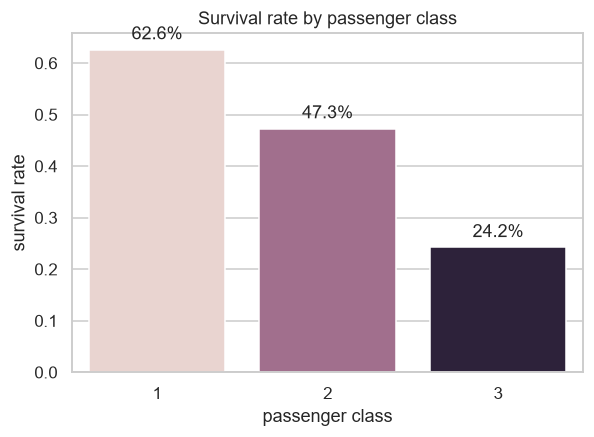

-> charts/bar_surv_by_pclass.png


In [7]:
# --- Chart 2/6: survival rate by pclass ---
rates_pc = clean.groupby("pclass")["survived"].mean()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=rates_pc.index, y=rates_pc.values, hue=rates_pc.index, legend=False, ax=ax)
for i, v in enumerate(rates_pc.values):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
ax.set_ylabel("survival rate")
ax.set_xlabel("passenger class")
ax.set_title("Survival rate by passenger class")
show_save(fig, "bar_surv_by_pclass.png")


**Chart 2 — Survival rate by passenger class.** 1st class **62.6%**, 2nd **47.3%**, 3rd **24.2%** — a
monotonic socio-economic gradient with no plateaus. Class encodes wealth, cabin location on the ship and
lifeboat proximity, so survival odds drop at every step down the ladder. This is the strongest *feature*
gradient after sex, and the correlation heatmap showed it in one number (pclass ↔ survival, r = −0.34).


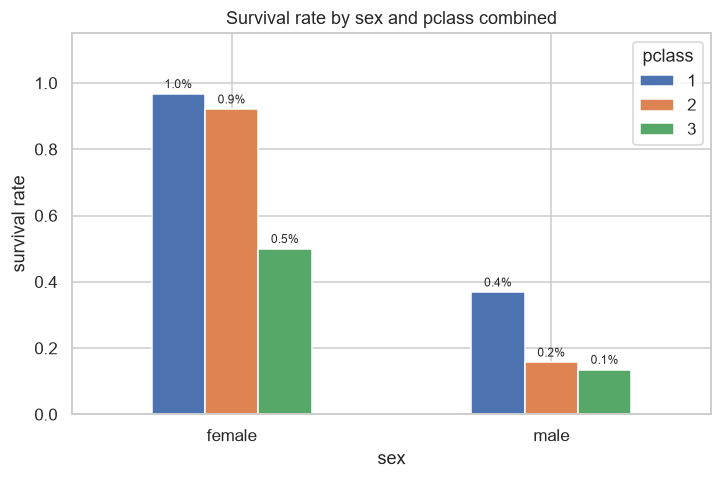

-> charts/bar_surv_sex_pclass.png


In [8]:
# --- Chart 3/6: survival rate by sex AND pclass (grouped bars) ---
piv = clean.groupby(["sex", "pclass"])["survived"].mean().unstack()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
piv.plot(kind="bar", ax=ax, rot=0, color=["#4C72B0", "#DD8452", "#55A868"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="edge", fontsize=8, padding=2)
ax.set_ylabel("survival rate")
ax.set_ylim(0, 1.15)
ax.set_title("Survival rate by sex and pclass combined")
ax.legend(title="pclass")
show_save(fig, "bar_surv_sex_pclass.png")


**Chart 3 — Sex × class interaction.** The two forces multiply, not just add: women in 1st and 2nd class
survived at **96.7%** and **92.1%** (nearly untouched groups), while men in 2nd and 3rd class dropped to
**15.7%** and **13.5%**. The spread across the six groups spans ~83 percentage points (96.7% → 13.5%),
proving survival was a structured privilege gradient rather than a coin flip — class is worth about half
as much as sex, but both matter enormously.


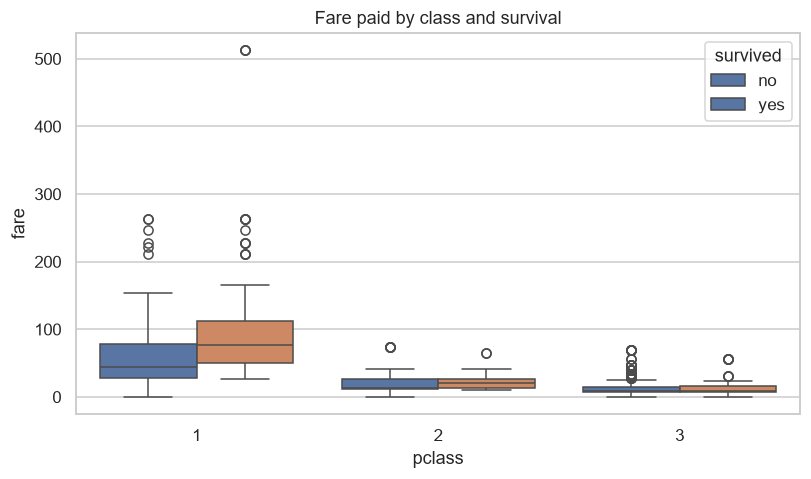

-> charts/box_fare_pclass_survived.png


In [9]:
# --- Chart 4/6: fare paid by class, split by survival ---
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.boxplot(data=clean, x="pclass", y="fare", hue="survived", ax=ax)
ax.set_title("Fare paid by class and survival")
ax.legend(title="survived", labels=["no", "yes"])
show_save(fig, "box_fare_pclass_survived.png")


**Chart 4 — Fare paid by class and survival.** Within every class, survivors' fare distributions sit
systematically *above* non-survivors', and fares soar from 3rd to 1st class. This is the visual form of the
strongest correlation in the matrix (pclass ↔ fare, r = −0.55): money bought cabin position, and cabin
position bought a lifeboat place. Fare is therefore a continuous proxy for the class effect, which is why
it predicts survival even within a single class.


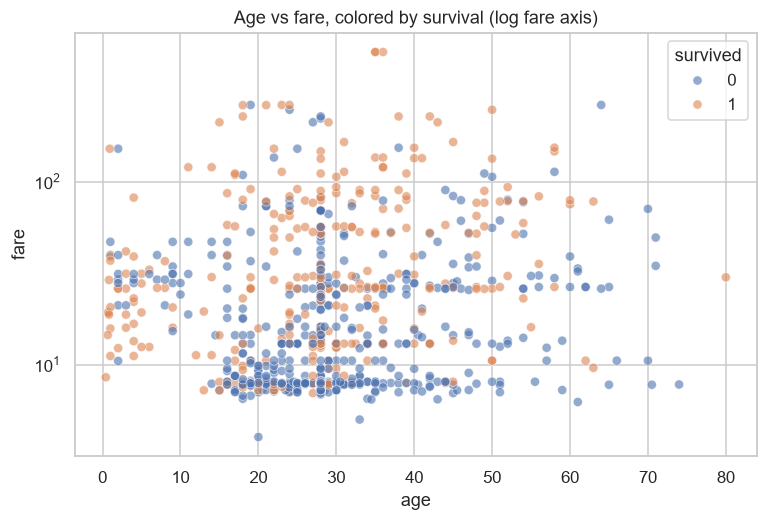

-> charts/scatter_age_fare.png


In [10]:
# --- Chart 5/6: age vs fare, colored by survival ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=clean, x="age", y="fare", hue="survived", alpha=0.6, ax=ax)
ax.set_yscale("log")
ax.set_title("Age vs fare, colored by survival (log fare axis)")
show_save(fig, "scatter_age_fare.png")


**Chart 5 — Age vs fare by survival.** On the log-fare axis, survivors (orange) spread across
medium-to-high fares at every age, while the dense low-fare cloud (≤ ~$25, typical of 3rd class) is
dominated by non-survivors. Age alone shows no blanket rule once fare/class and sex are accounted for —
which matches the numbers: age has the weakest raw correlation with survival of the six numeric columns
(r = −0.07). The chart's real message is that *fare*, not age, drives the visual separation.


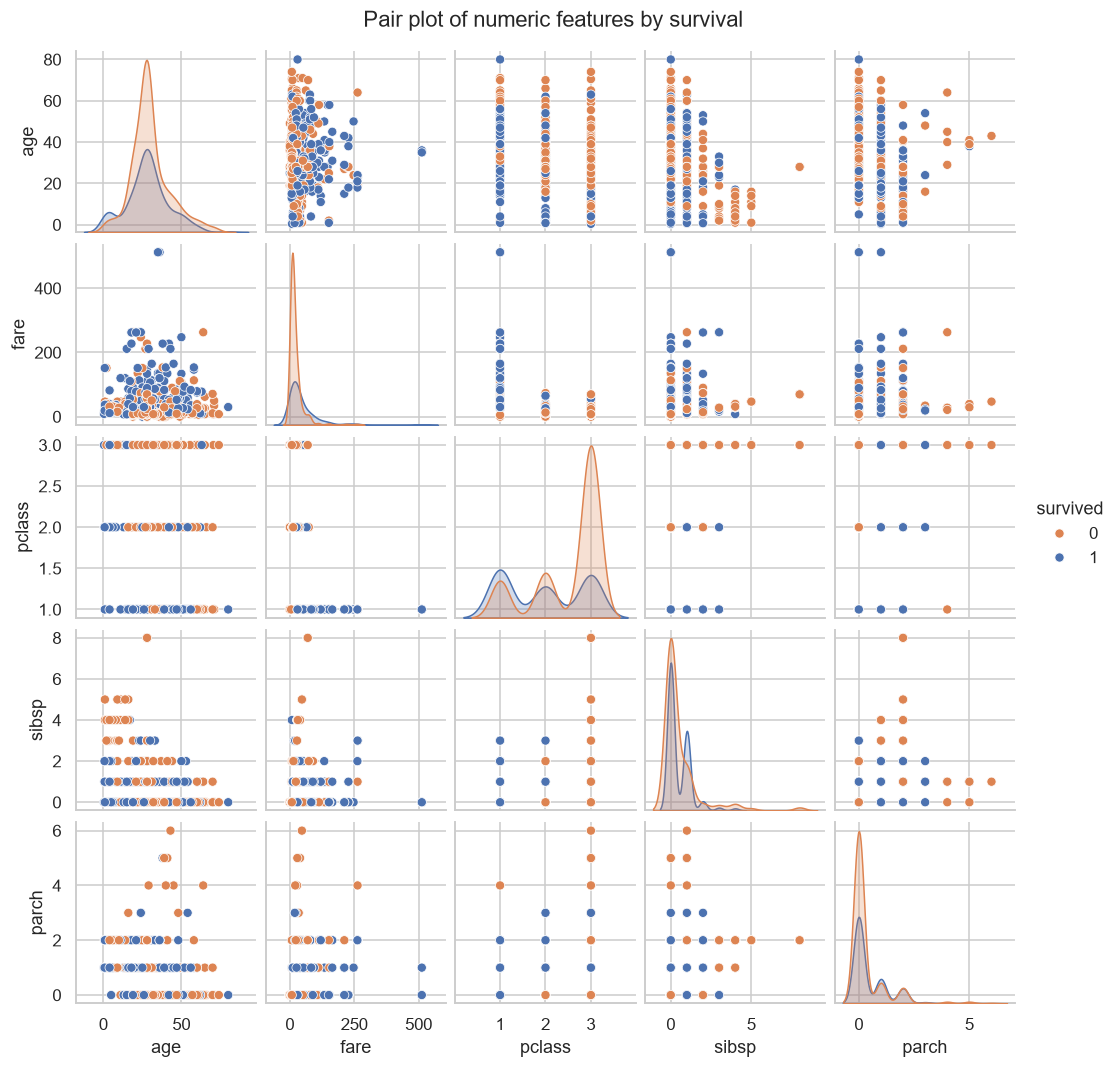

-> charts/pairplot.png


In [11]:
# --- Chart 6/6: pair plot of the key numeric features by survival ---
pp = sns.pairplot(
    clean.assign(survived=clean["survived"].astype(str)),
    vars=["age", "fare", "pclass", "sibsp", "parch"],
    hue="survived", height=1.9, palette=["#DD8452", "#4C72B0"],
)
pp.figure.suptitle("Pair plot of numeric features by survival", y=1.02)
pp.savefig("charts/pairplot.png", dpi=140)
plt.show()
plt.close("all")
print("-> charts/pairplot.png")


**Chart 6 — Pair plot of the numeric features by survival.** Panels confirm the story piece by piece:
survivors sit at higher fare values (fare row), shifted toward *low* pclass (pclass row), and the
sibsp-parch scatter (r = 0.41) shows family groups overlapping strongly with survival. The age panels show
heavy orange/blue overlap — age contributes little independent signal once sex, class and fare are known.
Together with Charts 1–5 the argument is complete: **female + 1st class + higher fare → survive;
male + 3rd class + low fare → perish**, with family size as a modest modifier.


### Task 6 — Exploratory standardization check (EDA-only, not fed to modeling)

We standardize `age` and `fare` with **z = (x − mean) / std** on the full cleaned DataFrame as a sanity
check that the formulas behave. This does **not** feed the modeling pipeline — Part B performs its own
train-only scaling inside its `ColumnTransformer`. Below: before/after mean & std tables plus overlaid
distributions.


BEFORE (raw):
           mean        std
age   29.315152  12.984932
fare  32.096681  49.697504

AFTER (z-scored):
      mean  std
age    0.0  1.0
fare   0.0  1.0


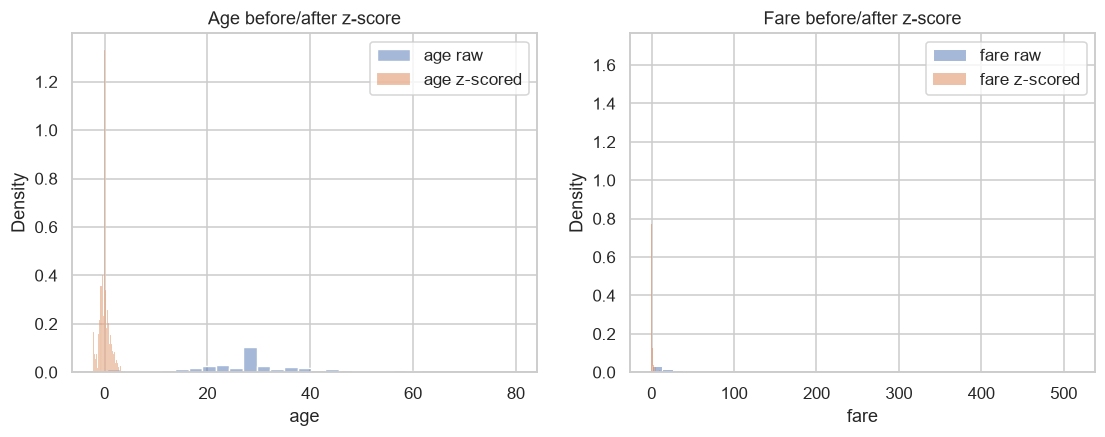

-> charts/zscore_before_after.png


In [12]:
z_age = (clean["age"] - clean["age"].mean()) / clean["age"].std()
z_fare = (clean["fare"] - clean["fare"].mean()) / clean["fare"].std()

before = pd.DataFrame({"mean": [clean["age"].mean(), clean["fare"].mean()],
                       "std": [clean["age"].std(), clean["fare"].std()]},
                      index=["age", "fare"]).round(6)
after = pd.DataFrame({"mean": [z_age.mean(), z_fare.mean()],
                      "std": [z_age.std(), z_fare.std()]},
                     index=["age", "fare"]).round(6)
print("BEFORE (raw):"); print(before.to_string())
print("\nAFTER (z-scored):"); print(after.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["age"], bins=30, stat="density", alpha=0.5, label="age raw", ax=axes[0])
sns.histplot(z_age, bins=30, stat="density", alpha=0.5, label="age z-scored", ax=axes[0])
axes[0].set_title("Age before/after z-score")
sns.histplot(clean["fare"], bins=40, stat="density", alpha=0.5, label="fare raw", ax=axes[1])
sns.histplot(z_fare, bins=40, stat="density", alpha=0.5, label="fare z-scored", ax=axes[1])
axes[1].set_title("Fare before/after z-score")
for a in axes:
    a.legend()
show_save(fig, "zscore_before_after.png")


The tables confirm both z-scored columns have **mean ≈ 0** and **std = 1** 

In [13]:
print("Part A complete.")
print(f"  raw titanic.csv committed : {df.shape}  (single raw load of the module)")
print(f"  cleaned in-memory frame   : {clean.shape}, no missing values")
print("Next: 02_modeling.ipynb reads titanic.csv -- no second dataset load anywhere.")


Part A complete.
  raw titanic.csv committed : (891, 15)  (single raw load of the module)
  cleaned in-memory frame   : (889, 14), no missing values
Next: 02_modeling.ipynb reads titanic.csv -- no second dataset load anywhere.
